# Introduction 

This Jupyter notebook was used to produce all of the plots in Boone (2019) showing the performance
of the avocado classifier on the PLAsTiCC dataset. To rerun this notebook, first follow the [steps on
avocado's readthedocs page](https://avocado-classifier.readthedocs.io/en/latest/plasticc.html) to
generate the datasets, produce the classifiers, and output the predictions that are analyzed in this
notebook. To run this notebook, copy it into your avocado working directory and run it using Jupyter.

This notebook has the same dependencies as avocado itself along with obviously requiring Jupyter to
be installed. Optionally, the [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/) package can
be installed to produce some interactive plots with widgets, although these can also all be viewed
non-interactively.

Note that the augmentation procedure in avocado is not deterministic, so the results will vary slightly
with every run. Most of the plots should not change very much, but plots that display specific light
curves from the augmented training set will be of completely different objects when run on a new
augmented training set.

# Configuration

In [45]:
# Choose which dataset to use.
dataset_name = 'plasticc_test'

In [46]:
# Use inline plots for github. Install ipywidgets, and change this to ipympl
# if you want to have interactive plots.
%matplotlib inline
# %matplotlib ipympl

In [47]:
# Default settings for matplotlib figures
import matplotlib as mpl

# Choose how big to make figures. This will scale the text size.
mpl.rcParams['figure.figsize'] = (5, 4)

# Set the DPI. This will change how big things appear in Jupyter lab
mpl.rcParams['figure.dpi'] = 120

In [48]:
# Choose which predictions to load. Note that each set of predictions takes a couple GB of RAM
# to load, so it isn't recommended to load everything at the same time. Simply comment out the
# predictions that you do not want to load.

# Predictions generated by avocado to use in the analysis.
avocado_predictions = {
    'redshift_weight_noaug': 'Redshift-weighted classifier (no aug)',
    'flat_weight_noaug': 'Flat-weighted classifier (no aug)',
}

# Predictions generated externally to use in the analysis.
# These were downloaded from the following thread on Kaggle:
# https://www.kaggle.com/c/PLAsTiCC-2018/discussion/75179
external_predictions = {
    # 'kaggle_kyle':  ('Kaggle - Kyle Boone', '../unblind/submissions/submission_1_kyle.csv'),
    # 'kaggle_mike_silogram': ('Kaggle - Mike & Silogram', '../unblind/submissions/submission_2_silogram.csv'),
    # 'kaggle_major_tom': ('Kaggle - Major Tom', '../unblind/submissions/submission_3_mamas.csv'),
    # 'kaggle_ahmet_erdem': ('Kaggle - AhmetErdem', '../unblind/submissions/submission_4_ahmet.csv'),
    # 'kaggle_skz' : ('Kaggle - SKZ', '../unblind/submissions/submission_5_cpmp.csv'),
}

In [49]:
# Labels for plots

plot_labels = {
    6: 'Single micro-lens - 6',
    15: 'TDE - 15',
    16: 'Eclipsing Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_short = {
    6: 'Single $\mu$-lens - 6',
    15: 'TDE - 15',
    16: 'Eclip. Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_extra_short = {
    6: 'Single $\mu$-lens',
    15: 'TDE',
    16: 'Eclip. Binary',
    42: 'SNII',
    52: 'SNIax',
    53: 'Mira',
    62: 'SNIbc',
    64: 'Kilonova',
    65: 'M-dwarf',
    67: 'SNIa-91bg',
    88: 'AGN',
    90: 'SNIa',
    92: 'RR lyrae',
    95: 'SLSN-I',
    99: 'Unknown',
}

# Python setup and utility funcitons

In [50]:
import avocado
import itertools
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.stats import binned_statistic

def plot_binned_mean(x, y, num_bins, **kwargs):
    means, bin_edges, binnumber = binned_statistic(x, y, bins=num_bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
    
    plt.plot(bin_centers, means, **kwargs)
    
os.makedirs('./figures', exist_ok=True)

# Load data

## Load the dataset

In [51]:
# print("Loading dataset...")
# dataset = avocado.load(dataset_name, metadata_only=True)

# # In the PLAsTiCC test data, the class 99 objects are split out. Combine them back together.
# dataset.metadata['raw_class'] = dataset.metadata['class']
# dataset.metadata['class'] = np.clip(dataset.metadata['class'], None, 99)

# # Setup the prediction arrays
# predictions = []
# kaggle_predictions = []
# prediction_names = []
# prediction_labels = []

# print("Done!")

print("Loading dataset...")
dataset = avocado.load(dataset_name, metadata_only=True)

# Load ALL features without chunking
features_path = avocado.settings['features_directory'] + '/features_v2_plasticc_test.h5'
dataset.raw_features = pd.read_hdf(features_path, 'raw_features')

# In the PLAsTiCC test data, the class 99 objects are split out. Combine them back together.
dataset.metadata['raw_class'] = dataset.metadata['class']
dataset.metadata['class'] = np.clip(dataset.metadata['class'], None, 99)

print(f"Metadata: {len(dataset.metadata)}")
print(f"Features: {len(dataset.raw_features)}")
print("Done!")

Loading dataset...
Metadata: 3492890
Features: 349289
Done!


## Load avocado-generated predictions

In [52]:
# print("Loading predictions...")

# for prediction_name, prediction_label in avocado_predictions.items():
#     print("    Loading %s..." % prediction_label)
#     prediction = dataset.load_predictions(prediction_name)
#     predictions.append(prediction)
#     kaggle_predictions.append(avocado.plasticc.create_kaggle_predictions(dataset, prediction))
#     prediction_names.append(prediction_name)
#     prediction_labels.append(prediction_label)
    
# print("Done!")

# print("Loading predictions...")

# for prediction_name, prediction_label in avocado_predictions.items():
#     print("    Loading %s..." % prediction_label)
    
#     all_preds = []
#     for i in range(5):
#         chunk_dataset = avocado.load(dataset_name, metadata_only=True, chunk=i, num_chunks=50)
#         chunk_dataset.load_predictions(prediction_name, verify_input_chunks=False)
#         all_preds.append(chunk_dataset.predictions)
    
#     prediction = pd.concat(all_preds).sort_index()
#     predictions.append(prediction)
#     prediction_names.append(prediction_name)
#     prediction_labels.append(prediction_label)

# print("Done!")

print("Loading predictions...")

predictions = []
prediction_names = []
prediction_labels = []

for prediction_name, prediction_label in avocado_predictions.items():
    print("    Loading %s..." % prediction_label)
    clf = avocado.load_classifier(prediction_name)
    prediction = dataset.predict(clf)
    predictions.append(prediction)
    prediction_names.append(prediction_name)
    prediction_labels.append(prediction_label)

print("Done!")

Loading predictions...
    Loading Redshift-weighted classifier (no aug)...


Classifier: 100%|██████████| 5/5 [00:20<00:00,  4.08s/it]


    Loading Flat-weighted classifier (no aug)...


Classifier:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] Unknown parameter: silent


...

[LightGBM] [Warning] Unknown parameter: silent


Classifier:  80%|████████  | 4/5 [01:05<00:16, 16.11s/it]

[LightGBM] [Warning] Unknown parameter: silent


Classifier: 100%|██████████| 5/5 [01:19<00:00, 15.98s/it]

Done!


## Load external predictions

In [53]:
def load_csv_prediction(path):
    # Read the prediction and convert it to our format.
    kaggle_prediction = pd.read_csv(path)
    kaggle_prediction.set_index('object_id', drop=True, inplace=True)
    kaggle_prediction.sort_index(inplace=True)
    
    kaggle_prediction.index = dataset.metadata.index
    kaggle_prediction.columns = [int(i.split('_')[1]) for i in kaggle_prediction.columns]
    kaggle_prediction = kaggle_prediction.reindex(sorted(kaggle_prediction.columns), axis=1)

    # Create a version of the prediction without class 99 predictions.
    prediction = kaggle_prediction.drop(99, axis=1)
    norm = np.sum(prediction, axis=1)
    prediction = prediction.div(norm, axis=0)
    
    return prediction, kaggle_prediction

In [54]:
print("Loading external predictions...")

for prediction_name, (prediction_label, path) in external_predictions.items():
    print("    Loading %s..." % prediction_label)
    prediction, kaggle_prediction = load_csv_prediction(path)

    predictions.append(prediction)
    kaggle_predictions.append(kaggle_prediction)
    prediction_names.append(prediction_name)
    prediction_labels.append(prediction_label)

Loading external predictions...


## Load the training set

In [12]:
d_train = avocado.load('plasticc_train')

# Load the features if they have been computed.
try:
    d_train.load_raw_features()
    d_train.select_features(avocado.plasticc.PlasticcFeaturizer());
except avocado.AvocadoException:
    print("Training set features not available! Some functionality will be missing!")

# Evaluate metrics

In [55]:
pred = predictions[0]
original_metadata = dataset.metadata
dataset.metadata = original_metadata.loc[pred.index]

# Redshift-weighted metric
redshift_object_weights = avocado.evaluate_weights_redshift(dataset, redshift_key='redshift')

print("Redshift-weighted metric:")
for prediction, prediction_label in zip(predictions, prediction_labels):
    scores = avocado.weighted_multi_logloss(
        dataset.metadata['class'],
        prediction,
        object_weights=redshift_object_weights,
        class_weights=avocado.plasticc.plasticc_flat_weights,
        return_object_contributions=True
    )
    print("%30s: %.5f" % (prediction_label, np.sum(scores)))

# Flat-weighted metric
print("\nFlat-weighted metric:")
for prediction, prediction_label in zip(predictions, prediction_labels):
    scores = avocado.weighted_multi_logloss(
        dataset.metadata['class'],
        prediction,
        class_weights=avocado.plasticc.plasticc_flat_weights,
    )
    print("%30s: %.5f" % (prediction_label, scores))

# Kaggle metric
print("\nKaggle metric:")
for prediction, prediction_label in zip(predictions, prediction_labels):
    kaggle_prediction = avocado.plasticc.create_kaggle_predictions(dataset, prediction)
    scores = avocado.weighted_multi_logloss(
        dataset.metadata['class'],
        kaggle_prediction,
        class_weights=avocado.plasticc.plasticc_kaggle_weights,
    )
    print("%30s: %.5f" % (prediction_label, scores))

dataset.metadata = original_metadata

Redshift-weighted metric:
Redshift-weighted classifier (no aug): 2.30825
Flat-weighted classifier (no aug): 1.13064

Flat-weighted metric:
Redshift-weighted classifier (no aug): 2.31648
Flat-weighted classifier (no aug): 1.11482

Kaggle metric:
Redshift-weighted classifier (no aug): 2.19055
Flat-weighted classifier (no aug): 1.10975


## Metric contributions by class

In [14]:
# Pick which scores to use for the plot

# scores = flat_metric_scores
# scores = kaggle_metric_scores
scores = redshift_metric_scores

In [15]:
object_classes = dataset.metadata['class']
class_names = np.unique(object_classes)

metric_contributions = np.zeros((len(predictions), len(class_names)))

for class_idx, class_name in enumerate(class_names):
    class_mask = object_classes == class_name
    for prediction_idx, score in enumerate(scores):
        class_contribution = np.sum(score[class_mask])
        metric_contributions[prediction_idx, class_idx] = class_contribution

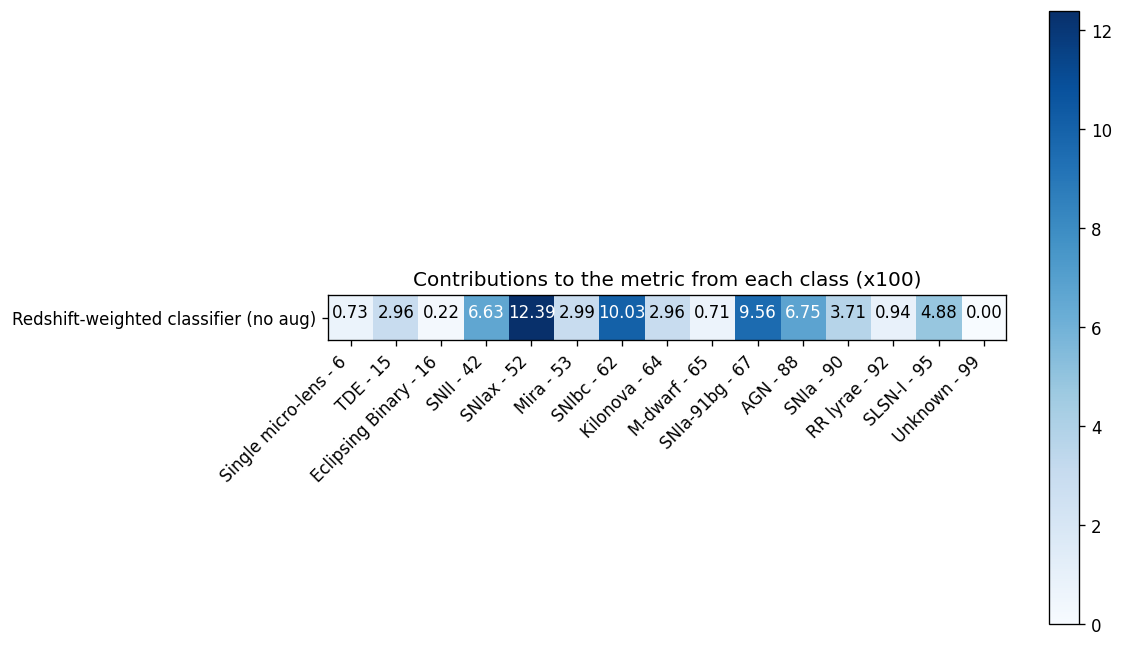

In [16]:
scale_mc = 100 * metric_contributions

plt.figure(figsize=(10, 5.5))
plt.imshow(scale_mc, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Contributions to the metric from each class (x100)')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, plot_labels.values(), rotation=45, ha='right')

yticks = prediction_labels
plt.yticks(np.arange(len(yticks)), yticks)

fmt = '.2f'
thresh = scale_mc.max() / 2.
for i, j in itertools.product(range(scale_mc.shape[0]), range(scale_mc.shape[1])):
    plt.text(j, i, format(scale_mc[i, j], fmt),
             horizontalalignment="center",
             color="white" if scale_mc[i, j] > thresh else "black")
    
plt.tight_layout()

# Confusion matrix

In [ ]:
# http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    im = plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=60, ha='right')
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.tight_layout()
    
    # Make a colorbar that is lined up with the plot
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.25)
    plt.colorbar(im, cax=cax, label='Fraction of objects')


def do_confusion_matrix(index, show_title=True):
    # Plot non-normalized confusion matrix
    plt.figure(figsize=(9,8))
    
    # Only include classes that we have predictions for
    true_classes = dataset.metadata['class']
    pred = predictions[index]

    # Align to only objects present in both
    common_idx = true_classes.index.intersection(pred.index)
    true_classes = true_classes.loc[common_idx]
    pred = pred.loc[common_idx]
    
    mask = true_classes.isin(pred.columns)
    
    mask_classes = true_classes[mask]
    # mask_pred = pred[mask_classes.index]
    mask_pred = pred.loc[mask_classes.index]

    true_indices = np.argmax(pd.get_dummies(mask_classes).values, axis=1)
    pred_indices = np.argmax(mask_pred.values, axis=-1)
    
    if show_title:
        title = 'Confusion matrix - %s' % prediction_labels[index]
    else:
        title = ''
        
    cnf_matrix = confusion_matrix(true_indices, pred_indices)
    plot_confusion_matrix(
        cnf_matrix,
        classes=[plot_labels_short[i] for i in pred.columns],
        normalize=True,
        title=title,
    )


Normalized confusion matrix


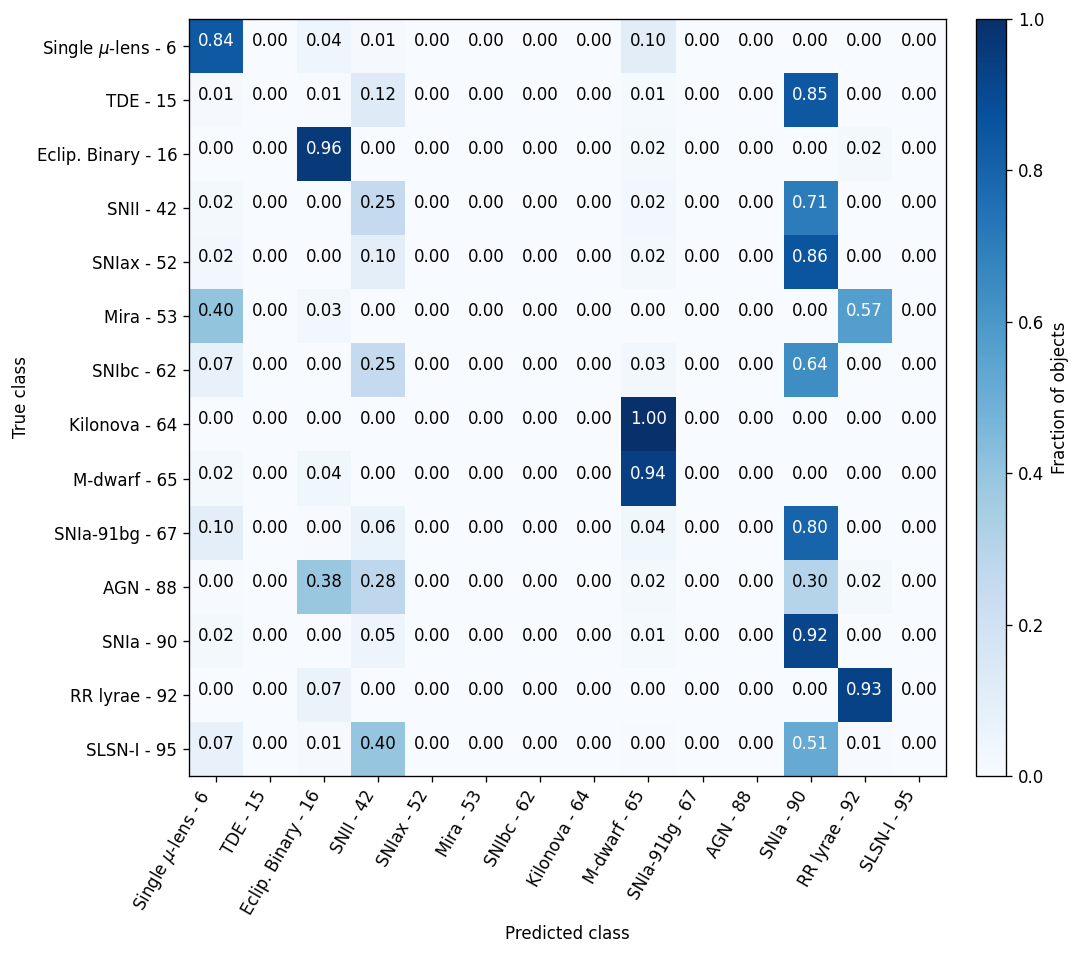

In [74]:
do_confusion_matrix(0, show_title=False)
plt.savefig('./figures/confusion_zW_matrix.pdf')

Normalized confusion matrix


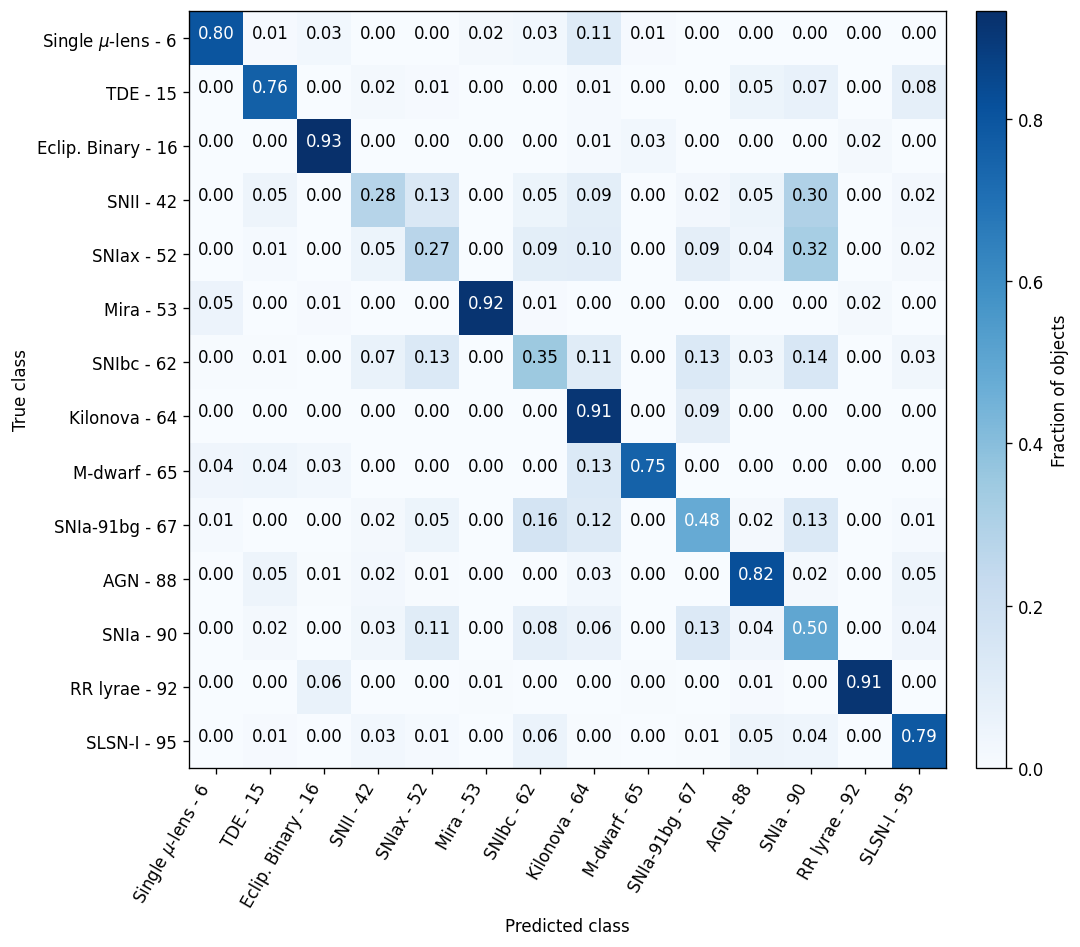

In [73]:
do_confusion_matrix(1, show_title=False)
plt.savefig('./figures/confusion_FW_matrix.pdf')

# ROC and precision-recall curves

## Utility functions for ROC and precision-recall curves

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import functools

In [26]:
def get_scores(prediction_index, target_class, reference_classes=None):
    """Retrieve the scores and class memberships given sets of target classes and reference classes
    
    Parameters
    ----------
    prediction_index : int
        The index of the prediction to use to calculate the scores.
    target_class : list
        The target class name, or a list of target class names.
    reference_classes : list (optional)
        A list of the reference class names. The reference classes must include the target classes.
        By default, all predictions are used which should sum to 1.
    
    Returns
    -------
    true_members : pandas.Series
        a Series indicating membership in the target classes. This will be True if the object is
        a member of those classes and False otherwise.
    scores : pandas.Series
        The scores for the target classes normalized to the reference class scores.
    """
    prediction = predictions[prediction_index]
    use_metadata = dataset.metadata
    
    # Check if we were passed a single class. We can do this by seeing if the
    # target class is hashable or not. Strings, floats, ints, etc. will be hashable
    # but lists, numpy arrays, etc. will not.
    try:
        hash(target_class)
        target_classes = [target_class]
    except TypeError:
        target_classes = target_class
    
    if reference_classes is not None:
        for class_name in target_classes:
            if class_name not in reference_classes:
                raise Exception("Class %s not in reference classes!" % class_name)

        mask = dataset.metadata['class'].isin(reference_classes)
        
        use_metadata = use_metadata[mask]
        prediction = prediction[mask]

        reference_scores = np.sum(prediction[reference_classes].values, axis=1)
    else:
        reference_scores = 1

    true_members = use_metadata['class'].isin(target_classes)

    target_scores = np.sum(prediction[target_classes].values, axis=1)

    scores = target_scores / reference_scores
    scores = pd.Series(scores, index=true_members.index)

    return true_members, scores

## Plot ROC curves

In [69]:
# Plot configuration

# -------------------------------------
# Pick a subset of classifiers to plot.
# -------------------------------------

# All
# selected_classifiers = None

# Paper
selected_classifiers = ['redshift_weight_noaug', 'flat_weight_noaug']

# --------------------------------------------------------
# Pick a set of reference classes to be comparing against.
# --------------------------------------------------------

# All (no 99)
reference_classes = None

# SNPCC targets
# reference_classes = [42, 62, 90]

# Galactic classes
# reference_classes = [6, 16, 53, 65, 92]

# Extragalactic classes
# reference_classes = [15, 42, 52, 62, 64, 67, 88, 90, 95]

In [70]:
def do_roc_curve(target_class, *args, **kwargs):
    """Generate a ROC curve for a set of target ids and reference ids"""
    plt.figure()
    
    print("AUCs for %s:" % plot_labels[target_class])

    for prediction_index, label in enumerate(prediction_labels):
        if selected_classifiers is not None and prediction_names[prediction_index] not in selected_classifiers:
            # Only plot selected classifiers
            continue
            
        true_members, scores = get_scores(prediction_index, target_class, *args, **kwargs)

        fpr, tpr, thresholds = roc_curve(true_members, scores)
        plt.plot(fpr, tpr, label=label)

        print("%35s: %.5f" % (label, auc(fpr, tpr)))

    plt.legend()

interactive(children=(Dropdown(description='target_class', index=11, options={'Single micro-lens - 6': 6, 'TDE…

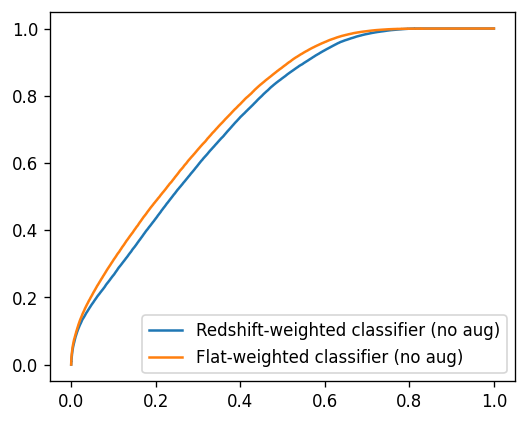

In [ ]:
# Interactive display of the ROC curves if ipywidgets is available.
from ipywidgets import interact, Dropdown

pred = predictions[0]
original_metadata = dataset.metadata
dataset.metadata = original_metadata.loc[pred.index]

if reference_classes:
    available_classes = reference_classes
else:
    available_classes = predictions[0].columns
    
target_widget = Dropdown(
    options={plot_labels[i]:i for i in available_classes},
    value=90,
)
interact(do_roc_curve, target_class=target_widget)

dataset.metadata = original_metadata #This interferes with the dropdown, but is necessary to keep metadata in the right order for the rest of the notebook. You could replace this in a different cell.

## Print AUCs for each target

In [61]:
def print_aucs(classifier_name, *args, **kwargs):
    """Generate a ROC curve for a set of target ids and reference ids"""
    for prediction_index, iter_name in enumerate(prediction_names):
        if classifier_name == iter_name:
            break
    else:
        raise Exception("No classifier with name %s" % classifier_name)

    print("AUCs for %s:" % prediction_labels[prediction_index])

    for class_id in np.unique(dataset.metadata['class']):
        try:
            true_members, scores = get_scores(prediction_index, class_id, *args, **kwargs)
        except KeyError:
            continue
            
        fpr, tpr, thresholds = roc_curve(true_members, scores)
        print("%35s: %.5f" % (plot_labels[class_id], auc(fpr, tpr)))

In [62]:
# print_aucs('redshift_weight_noaug')

pred = predictions[0]
original_metadata = dataset.metadata
dataset.metadata = original_metadata.loc[pred.index]

print_aucs('redshift_weight_noaug')

dataset.metadata = original_metadata

AUCs for Redshift-weighted classifier (no aug):
              Single micro-lens - 6: 0.95874
                           TDE - 15: 0.69455
              Eclipsing Binary - 16: 0.99805
                          SNII - 42: 0.67357
                         SNIax - 52: 0.55755
                          Mira - 53: 0.53883
                         SNIbc - 62: 0.68502
                      Kilonova - 64: 0.23824
                       M-dwarf - 65: 0.99415
                     SNIa-91bg - 67: 0.57870
                           AGN - 88: 0.67878
                          SNIa - 90: 0.73550
                      RR lyrae - 92: 0.99828
                        SLSN-I - 95: 0.76259


In [63]:
pred = predictions[0]
original_metadata = dataset.metadata
dataset.metadata = original_metadata.loc[pred.index]

print_aucs('flat_weight_noaug')

dataset.metadata = original_metadata

AUCs for Flat-weighted classifier (no aug):
              Single micro-lens - 6: 0.98822
                           TDE - 15: 0.96811
              Eclipsing Binary - 16: 0.99814
                          SNII - 42: 0.74004
                         SNIax - 52: 0.67730
                          Mira - 53: 0.99930
                         SNIbc - 62: 0.78218
                      Kilonova - 64: 0.99478
                       M-dwarf - 65: 0.99795
                     SNIa-91bg - 67: 0.84124
                           AGN - 88: 0.98115
                          SNIa - 90: 0.76088
                      RR lyrae - 92: 0.99911
                        SLSN-I - 95: 0.96887


## Plot completeness vs redshift

In [64]:
# Default plot configuration

# -------------------------------------
# Pick a subset of classifiers to plot.
# -------------------------------------

# All
# selected_classifiers = None

# Paper
selected_classifiers = ['redshift_weight_noaug', 'flat_weight_noaug']

# --------------------------------------------------------
# Pick a class for the plot
# --------------------------------------------------------

class_id = 90

# --------------------------------------------------------
# Choose the purity level.
# --------------------------------------------------------

target_purity = 0.95

# --------------------------------------------------------
# Choose DDF or WFD
# --------------------------------------------------------

ddf = False

In [65]:
def evaluate_threshold(prediction_index, target_purity, class_id):
    """Determine the threshold to cut at for a given purity."""
    true_members, scores = get_scores(prediction_index, class_id, reference_classes=None)
    
    purity, completeness, thresholds = precision_recall_curve(true_members, scores)

    loc = np.argmin(np.abs(purity - target_purity))
    
    print("%35s: threshold = %.2f, completeness = %.2f" % (prediction_labels[prediction_index], thresholds[loc], completeness[loc]))
    
    return thresholds[loc]

def plot_completeness(ddf=ddf, target_purity=target_purity, class_id=class_id, selected_classifiers=selected_classifiers, labels=None):
    """Plot the completeness as a function of redshift for a given purity."""
    # Figure out which predictions to use
    if selected_classifiers is None:
        prediction_indices = np.arange(len(prediction_names))
    else:
        prediction_indices = [i for i, name in enumerate(prediction_names) if name in selected_classifiers]

    # Figure out the thresholds for each sample to achieve the target purity.
    use_thresholds = []
    print("Thresholds for purity = %.2f for %s" % (target_purity, plot_labels[class_id]))
    for prediction_index in prediction_indices:
        threshold = evaluate_threshold(prediction_index, target_purity, class_id)
        use_thresholds.append(threshold)

    class_cut = dataset.metadata['class'] == class_id
    ddf_cut = dataset.metadata['ddf']

    if ddf:
        cut = class_cut & ddf_cut
        title = 'DDF survey'
    else:
        cut = class_cut & ~ddf_cut
        title = 'WFD survey'

    cut_metadata = dataset.metadata[cut]

    plt.figure()
    plt.title(title)

    for plot_index, prediction_index in enumerate(prediction_indices):
        prediction = predictions[prediction_index]
        cut_prediction = prediction[cut]

        correct = cut_prediction[class_id] > use_thresholds[plot_index]
        
        if labels is None:
            label = prediction_labels[prediction_index]
        else:
            label = labels[plot_index]

        plot_binned_mean(
            cut_metadata['redshift'], correct, 20, label=label,
        )

    plt.legend(loc=3)
    plt.ylim(0, 1)
    plt.xlabel('Redshift')
    plt.ylabel('Completeness')
    plt.tight_layout()

Thresholds for purity = 0.95 for SNIa - 90
Redshift-weighted classifier (no aug): threshold = 0.71, completeness = 0.01
  Flat-weighted classifier (no aug): threshold = 0.66, completeness = 0.03


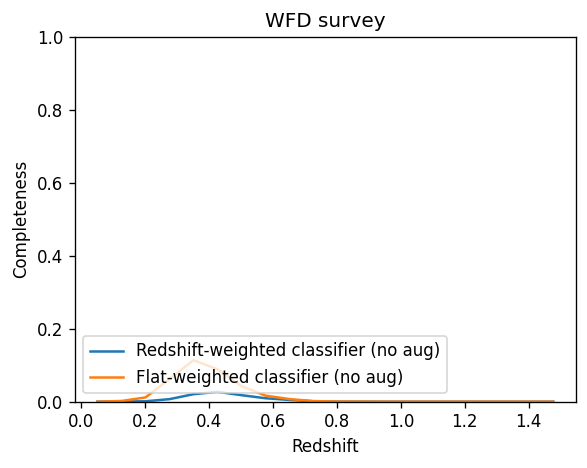

In [66]:
pred = predictions[0]
original_metadata = dataset.metadata
dataset.metadata = original_metadata.loc[pred.index]

plot_completeness(ddf=False)
plt.savefig('./figures/completeness_wfd.pdf')

Thresholds for purity = 0.95 for SNIa - 90
Redshift-weighted classifier (no aug): threshold = 0.71, completeness = 0.01
  Flat-weighted classifier (no aug): threshold = 0.66, completeness = 0.03


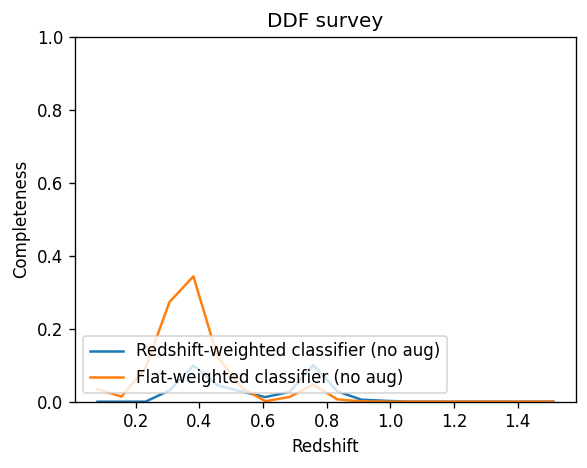

In [67]:
plot_completeness(ddf=True)
plt.savefig('./figures/completeness_ddf.pdf')

dataset.metadata = original_metadata

# Feature importance plots

In [39]:
def plot_feature_importances(classifier_name):
    classifier = avocado.load_classifier(classifier_name)
    
    importances = classifier.importances
    
    # Normalize the importances for the classifiers trained on each fold.
    importances['normed_gain'] = 0.
    for fold in np.unique(importances['fold']):
        fold_mask = importances['fold'] == fold
        norm = np.sum(importances[fold_mask]['gain']) / 1000.
        importances.loc[fold_mask, 'normed_gain'] = importances.loc[fold_mask, 'gain'] / norm
    
    stats = classifier.importances.groupby('feature')['normed_gain'].aggregate(['mean', 'max', 'min'])
    stats.sort_values('mean', inplace=True, ascending=True)
    
    stats['min_diff'] = stats['mean'] - stats['min']
    stats['max_diff'] = stats['max'] - stats['mean']
    
    count = len(stats)
    plt.figure(figsize=(8, 8))
    plt.barh(range(count), stats['mean'][:count], xerr=(stats['min_diff'][:count], stats['max_diff'][:count]), align="center", alpha=0.5)
    plt.yticks(range(count), stats.index[:count])
    plt.gca().invert_yaxis()
    plt.xlabel('Relative importance of feature for classification')
    plt.ylim(-0.7, count-0.3)
    plt.tight_layout()
    
    plt.savefig('./figures/%s_importances.pdf' % classifier_name)

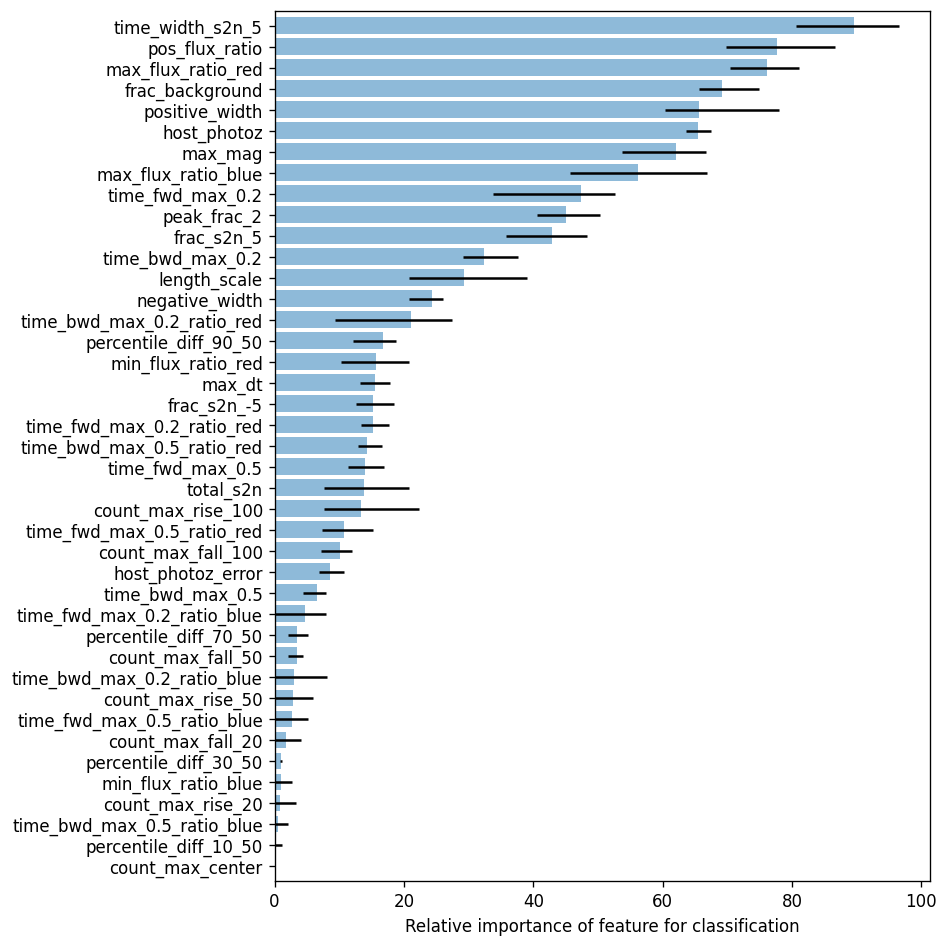

In [40]:
plot_feature_importances('redshift_weight_noaug')

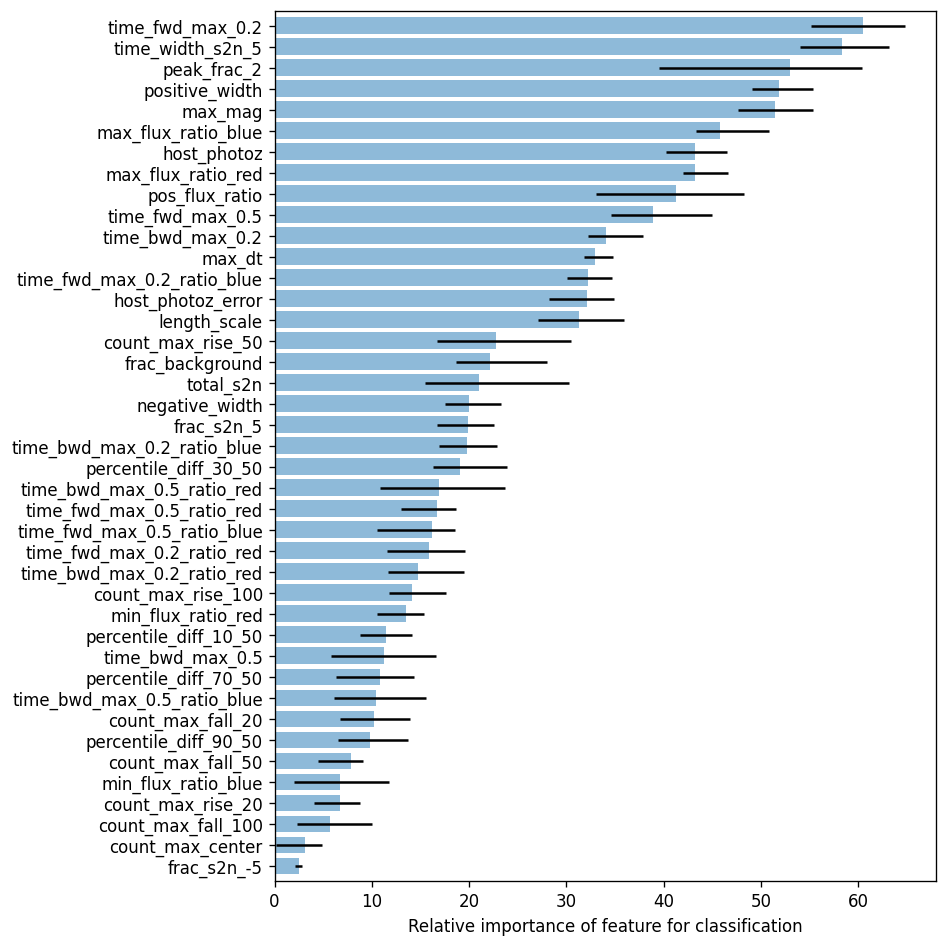

In [68]:
plot_feature_importances('flat_weight_noaug')